## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc

from tqdm.notebook import tqdm

beta here denotes exponent in the drag coefficient correction

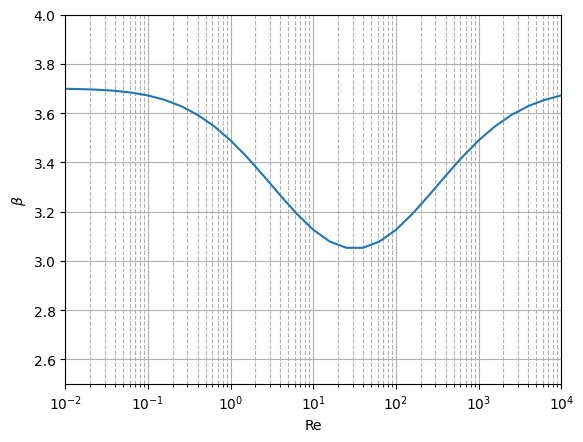

In [2]:
power = np.arange(-2, 5, step=0.2)
Re_vec = 10**power

beta = lambda Re: 3.7 - 0.65*np.exp(
        -0.5 * (1.5 - np.log10(Re))**2
    )

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=beta(Re_vec),
    ax=ax,
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1*10**-2, 10**4)
ax.set_ylim(2.5, 4)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel(r'$\beta$');

Compare with source plot [DiFelice1994VoidageFunction]:

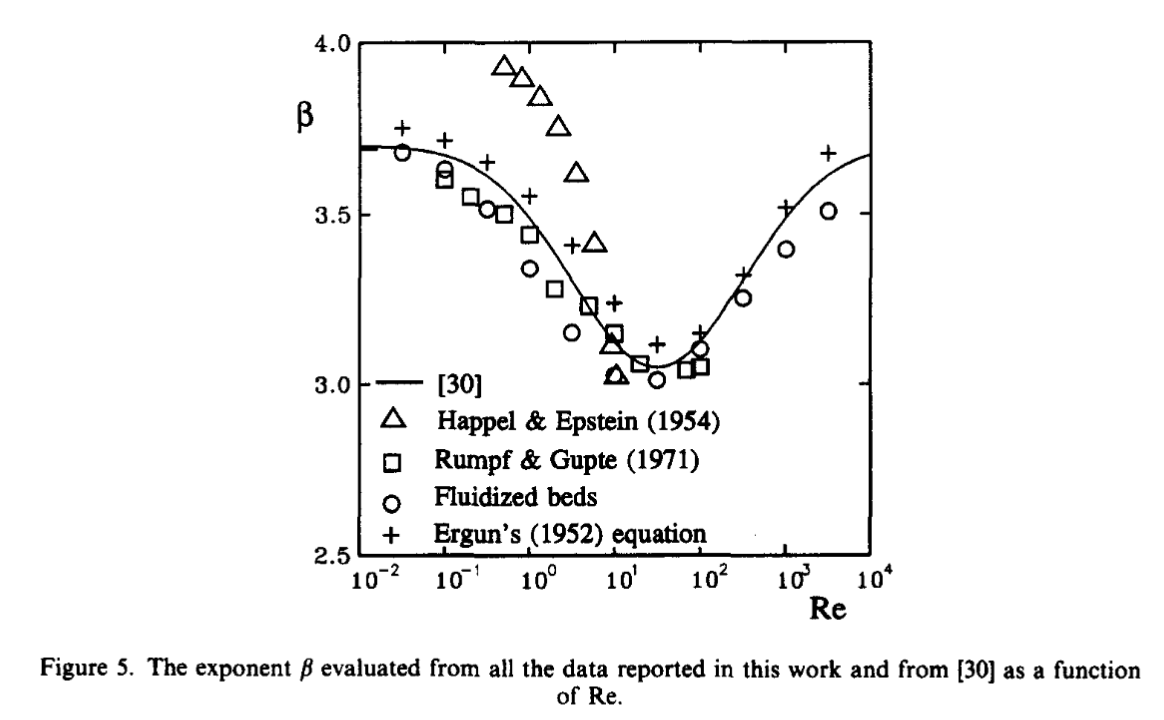

## Drag coefficient plot vs sedimentation drag coefficient plot

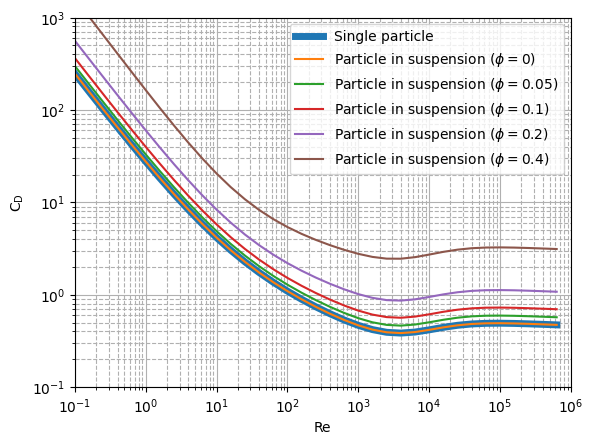

In [3]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
    label='Single particle',
    linewidth=5,
)

phi = 0
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.05
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.10
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.20
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.40
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$')
ax.legend();

## Test Sedimentation System

Consider Oz oriented down.

Upstream scheme

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 1)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004  0.0041 0.0042 0.0043 0.0044 0.0045 0.0046 0.0047 0.0048 0.0049
 0.005  0.0051 0.0052 0.0053 0.0054 0.0055 0.0056 0.0057 0.0058 0.0059
 0.006  0.0061 0.0062 0.0063 0.0064 0.0065 0.0066 0.0067 0.0068 0.0069
 0.007  0.0071 0.0072 0.0073 0.0074 0.0075 0.0076 0.0077 0.0078 0.0079
 0.008  0.0081 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01  ]
v_p [m/s] = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 

In [6]:
index_t = 10
t = numerical_results.t[index_t]
print(f'INTERIM, t= {t} s')
z_p, v_p, phi, q_phi = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

INTERIM, t= 0.01001001001001001 s
z_p [m] = [2.80723700e-07 1.00280724e-04 2.00280724e-04 3.00280724e-04
 4.00280724e-04 5.00280724e-04 6.00280724e-04 7.00280724e-04
 8.00280724e-04 9.00280724e-04 1.00028072e-03 1.10028072e-03
 1.20028072e-03 1.30028072e-03 1.40028072e-03 1.50028072e-03
 1.60028072e-03 1.70028072e-03 1.80028072e-03 1.90028072e-03
 2.00028072e-03 2.10028072e-03 2.20028072e-03 2.30028072e-03
 2.40028072e-03 2.50028072e-03 2.60028072e-03 2.70028072e-03
 2.80028072e-03 2.90028072e-03 3.00028072e-03 3.10028072e-03
 3.20028072e-03 3.30028072e-03 3.40028072e-03 3.50028072e-03
 3.60028072e-03 3.70028072e-03 3.80028072e-03 3.90028072e-03
 4.00028072e-03 4.10028072e-03 4.20028072e-03 4.30028072e-03
 4.40028072e-03 4.50028072e-03 4.60028072e-03 4.70028072e-03
 4.80028072e-03 4.90028072e-03 5.00028072e-03 5.10028072e-03
 5.20028072e-03 5.30028072e-03 5.40028072e-03 5.50028072e-03
 5.60028072e-03 5.70028072e-03 5.80028072e-03 5.90028072e-03
 6.00028072e-03 6.10028072e-03 6.20028072

Downstream - unstable!

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 1)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004  0.0041 0.0042 0.0043 0.0044 0.0045 0.0046 0.0047 0.0048 0.0049
 0.005  0.0051 0.0052 0.0053 0.0054 0.0055 0.0056 0.0057 0.0058 0.0059
 0.006  0.0061 0.0062 0.0063 0.0064 0.0065 0.0066 0.0067 0.0068 0.0069
 0.007  0.0071 0.0072 0.0073 0.0074 0.0075 0.0076 0.0077 0.0078 0.0079
 0.008  0.0081 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01  ]
v_p [m/s] = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 

Вывод: градиент концентрации возникает, однако он имеется только в тех 6 ячейках, где скорость явным образом умножается на коэффициент от 1 до 0! Возможно, причина ещё в том, что скорость изменения концентрации в верхнем узле постоянна.